# Movie Recommendation System

An end-to-end movie recommender built on the **MovieLens 1M** dataset (1,000,209 ratings, 3,883 movies, 6,040 users).

This notebook covers:
1. Data loading & exploratory data analysis (EDA)
2. **Content-based filtering** (TF-IDF on genres + cosine similarity)
3. **Collaborative filtering** (matrix factorization via truncated SVD), trained/evaluated with a held-out test set
4. A **hybrid recommender** that blends both signals
5. Sample recommendations for a movie and for a user


## 1. Setup & Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.sparse import csr_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import linear_kernel, cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import mean_squared_error

pd.set_option('display.max_colwidth', 80)
plt.style.use('seaborn-v0_8-whitegrid')
np.random.seed(42)


## 2. Load the Data

Dataset: MovieLens 1M (`movies.csv`, `ratings.csv`), sourced from a public GitHub mirror of the GroupLens MovieLens 1M release. Files are tab-separated with a leading index column. The cell below downloads the two CSVs into a local `data/` folder if they aren't already present.

In [2]:
import os, urllib.request

os.makedirs('data', exist_ok=True)
BASE_URL = 'https://raw.githubusercontent.com/khanhnamle1994/movielens/master'

for fname in ['movies.csv', 'ratings.csv']:
    fpath = os.path.join('data', fname)
    if not os.path.exists(fpath):
        print(f"Downloading {fname} ...")
        urllib.request.urlretrieve(f'{BASE_URL}/{fname}', fpath)
print("Data ready.")


Data ready.


In [3]:
movies = pd.read_csv('data/movies.csv', sep='\t', index_col=0, encoding='latin-1')
ratings = pd.read_csv('data/ratings.csv', sep='\t', index_col=0, encoding='latin-1')[['user_id', 'movie_id', 'rating']]

print(f"Movies : {movies.shape}")
print(f"Ratings: {ratings.shape}")
movies.head()


Movies : (3883, 3)
Ratings: (1000209, 3)


,movie_id,title,genres
0,1,Toy Story (1995),Animation|Children's|Comedy
1,2,Jumanji (1995),Adventure|Children's|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama
4,5,Father of the Bride Part II (1995),Comedy


In [4]:
ratings.head()


,user_id,movie_id,rating
0,1,1193,5
1,1,661,3
2,1,914,3
3,1,3408,4
4,1,2355,5


## 3. Exploratory Data Analysis

In [5]:
print(ratings['rating'].describe())
print()
print(f"Unique users : {ratings['user_id'].nunique()}")
print(f"Unique movies: {ratings['movie_id'].nunique()}")
print(f"Sparsity     : {1 - len(ratings) / (ratings['user_id'].nunique() * ratings['movie_id'].nunique()):.4%}")


count    1.000209e+06
mean     3.581564e+00
std      1.117102e+00
min      1.000000e+00
25%      3.000000e+00
50%      4.000000e+00
75%      4.000000e+00
max      5.000000e+00
Name: rating, dtype: float64

Unique users : 6040
Unique movies: 3706
Sparsity     : 95.5316%


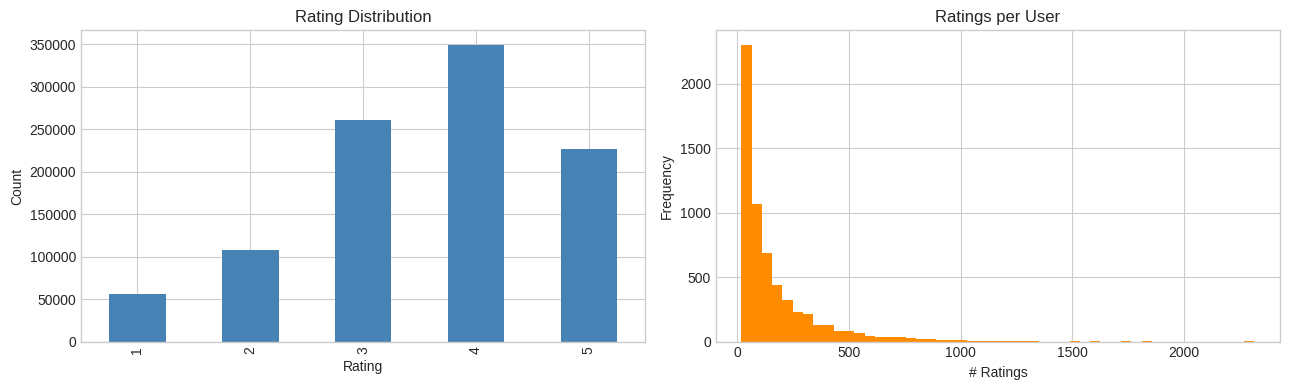

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ratings['rating'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Rating Distribution')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Count')

ratings.groupby('user_id').size().plot(kind='hist', bins=50, ax=axes[1], color='darkorange')
axes[1].set_title('Ratings per User')
axes[1].set_xlabel('# Ratings')

plt.tight_layout()
plt.show()


In [7]:
# Most-rated movies
rating_counts = ratings.groupby('movie_id').size().rename('num_ratings')
avg_ratings = ratings.groupby('movie_id')['rating'].mean().rename('avg_rating')
movie_stats = movies.set_index('movie_id').join(rating_counts).join(avg_ratings)

print("Top 10 most-rated movies:")
movie_stats.sort_values('num_ratings', ascending=False)[['title', 'num_ratings', 'avg_rating']].head(10)


Top 10 most-rated movies:


,title,num_ratings,avg_rating
movie_id,,,
2858,American Beauty (1999),3428.0,4.317386
260,Star Wars: Episode IV - A New Hope (1977),2991.0,4.453694
1196,Star Wars: Episode V - The Empire Strikes Back (1980),2990.0,4.292977
1210,Star Wars: Episode VI - Return of the Jedi (1983),2883.0,4.022893
480,Jurassic Park (1993),2672.0,3.763847
2028,Saving Private Ryan (1998),2653.0,4.337354
589,Terminator 2: Judgment Day (1991),2649.0,4.058513
2571,"Matrix, The (1999)",2590.0,4.315830
1270,Back to the Future (1985),2583.0,3.990321


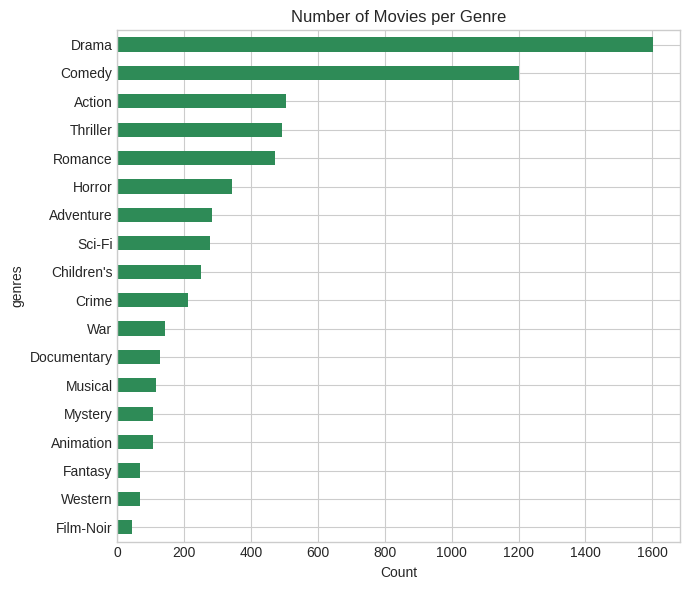

In [8]:
# Genre popularity
genre_counts = movies['genres'].str.split('|').explode().value_counts()
genre_counts.plot(kind='barh', figsize=(7, 6), color='seagreen')
plt.title('Number of Movies per Genre')
plt.xlabel('Count')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


## 4. Content-Based Filtering

Represent each movie by its genres using **TF-IDF**, then recommend movies whose genre profile is most similar (cosine similarity) to a given movie.

In [9]:
movies = movies.reset_index(drop=True)
movies['genres_clean'] = movies['genres'].str.replace('|', ' ', regex=False)

tfidf = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf.fit_transform(movies['genres_clean'])
print(f"TF-IDF matrix shape: {tfidf_matrix.shape}")

content_sim = linear_kernel(tfidf_matrix, tfidf_matrix)
title_to_idx = pd.Series(movies.index, index=movies['title']).drop_duplicates()


TF-IDF matrix shape: (3883, 20)


In [10]:
def recommend_by_content(title, n=10):
    """Return the n movies most similar to `title` based on genre overlap."""
    if title not in title_to_idx:
        raise ValueError(f"'{title}' not found in the catalogue.")
    idx = title_to_idx[title]
    scores = list(enumerate(content_sim[idx]))
    scores = sorted(scores, key=lambda x: x[1], reverse=True)[1:n + 1]
    result_idx = [i for i, _ in scores]
    result = movies.loc[result_idx, ['title', 'genres']].copy()
    result['similarity'] = [s for _, s in scores]
    return result.reset_index(drop=True)

recommend_by_content('Toy Story (1995)', n=10)


,title,genres,similarity
0,Aladdin and the King of Thieves (1996),Animation|Children's|Comedy,1.000000
1,"American Tail, An (1986)",Animation|Children's|Comedy,1.000000
2,"American Tail: Fievel Goes West, An (1991)",Animation|Children's|Comedy,1.000000
3,"Rugrats Movie, The (1998)",Animation|Children's|Comedy,1.000000
4,"Bug's Life, A (1998)",Animation|Children's|Comedy,1.000000
5,Toy Story 2 (1999),Animation|Children's|Comedy,1.000000
6,Saludos Amigos (1943),Animation|Children's|Comedy,1.000000
7,Chicken Run (2000),Animation|Children's|Comedy,1.000000
8,"Adventures of Rocky and Bullwinkle, The (2000)",Animation|Children's|Comedy,1.000000
9,Balto (1995),Animation|Children's,0.938841


## 5. Collaborative Filtering (Matrix Factorization)

Build the sparse user-item ratings matrix, mean-center it, and factorize with **Truncated SVD**. This learns latent taste dimensions purely from rating patterns (no genre metadata), so it can surface recommendations content-based filtering would miss.

We hold out 20% of ratings to measure RMSE against a mean-rating baseline.

In [11]:
train_ratings, test_ratings = train_test_split(ratings, test_size=0.2, random_state=42)

user_ids = ratings['user_id'].unique()
movie_ids = ratings['movie_id'].unique()
user_map = {u: i for i, u in enumerate(user_ids)}
movie_map = {m: i for i, m in enumerate(movie_ids)}
inv_movie_map = {i: m for m, i in movie_map.items()}

n_users, n_movies = len(user_ids), len(movie_ids)
global_mean = train_ratings['rating'].mean()
print(f"Users: {n_users}, Movies: {n_movies}, Global mean rating: {global_mean:.3f}")

def build_matrix(df):
    rows = df['user_id'].map(user_map)
    cols = df['movie_id'].map(movie_map)
    vals = df['rating'] - global_mean          # mean-center observed ratings
    return csr_matrix((vals, (rows, cols)), shape=(n_users, n_movies))

train_matrix = build_matrix(train_ratings)


Users: 6040, Movies: 3706, Global mean rating: 3.581


In [12]:
N_COMPONENTS = 20
svd = TruncatedSVD(n_components=N_COMPONENTS, random_state=42)
user_factors = svd.fit_transform(train_matrix)   # (n_users, k)
item_factors = svd.components_                    # (k, n_movies)

pred_matrix = user_factors.dot(item_factors) + global_mean
pred_matrix = np.clip(pred_matrix, 1, 5)

print(f"Explained variance ratio (top {N_COMPONENTS} components): {svd.explained_variance_ratio_.sum():.3f}")


Explained variance ratio (top 20 components): 0.148


In [13]:
# Evaluate against a held-out test set
test_rows = test_ratings['user_id'].map(user_map).values
test_cols = test_ratings['movie_id'].map(movie_map).values
test_preds = pred_matrix[test_rows, test_cols]

svd_rmse = mean_squared_error(test_ratings['rating'], test_preds) ** 0.5
baseline_rmse = mean_squared_error(test_ratings['rating'], np.full(len(test_ratings), global_mean)) ** 0.5

print(f"Baseline (global mean) RMSE : {baseline_rmse:.4f}")
print(f"SVD collaborative filter RMSE: {svd_rmse:.4f}")
print(f"Improvement over baseline    : {(baseline_rmse - svd_rmse) / baseline_rmse:.2%}")


Baseline (global mean) RMSE : 1.1197
SVD collaborative filter RMSE: 1.0079
Improvement over baseline    : 9.99%


In [14]:
def recommend_by_cf(user_id, n=10, exclude_seen=True):
    """Top-n movies for a user, ranked by predicted rating from the SVD model."""
    if user_id not in user_map:
        raise ValueError(f"user_id {user_id} not found.")
    u_idx = user_map[user_id]
    scores = pred_matrix[u_idx]

    if exclude_seen:
        seen = set(ratings.loc[ratings['user_id'] == user_id, 'movie_id'])
        seen_idx = [movie_map[m] for m in seen if m in movie_map]
        scores = scores.copy()
        scores[seen_idx] = -np.inf

    top_idx = np.argsort(scores)[::-1][:n]
    rec_movie_ids = [inv_movie_map[i] for i in top_idx]
    result = movies.set_index('movie_id').loc[rec_movie_ids, ['title', 'genres']].copy()
    result['predicted_rating'] = scores[top_idx]
    return result.reset_index()

recommend_by_cf(user_id=1, n=10)


,movie_id,title,genres,predicted_rating
0,356,Forrest Gump (1994),Comedy|Romance|War,4.136829
1,318,"Shawshank Redemption, The (1994)",Drama,3.974611
2,34,Babe (1995),Children's|Comedy|Drama,3.924954
3,590,Dances with Wolves (1990),Adventure|Drama|Western,3.896372
4,364,"Lion King, The (1994)",Animation|Children's|Musical,3.868407
5,480,Jurassic Park (1993),Action|Adventure|Sci-Fi,3.831522
6,593,"Silence of the Lambs, The (1991)",Drama|Thriller,3.831423
7,110,Braveheart (1995),Action|Drama|War,3.823631
8,2081,"Little Mermaid, The (1989)",Animation|Children's|Comedy|Musical|Romance,3.822284
9,2716,Ghostbusters (1984),Comedy|Horror,3.808151


## 6. Hybrid Recommender

Blend the two signals: for a user, take their highest-rated movies as "seeds", pull content-similar candidates for each seed, and re-rank those candidates by the user's *predicted CF rating*. This tends to surface titles that match the user's taste profile (CF) while staying genre-relevant (content) — useful for justifying *why* something was recommended.

In [15]:
def recommend_hybrid(user_id, n=10, n_seeds=5):
    user_ratings = ratings[ratings['user_id'] == user_id].sort_values('rating', ascending=False)
    seed_movie_ids = user_ratings['movie_id'].head(n_seeds).tolist()
    seed_titles = movies.set_index('movie_id').loc[
        [m for m in seed_movie_ids if m in movies['movie_id'].values], 'title'
    ]

    candidate_idx = set()
    for title in seed_titles:
        idx = title_to_idx[title]
        sims = list(enumerate(content_sim[idx]))
        sims = sorted(sims, key=lambda x: x[1], reverse=True)[1:20]
        candidate_idx.update(i for i, _ in sims)

    seen = set(user_ratings['movie_id'])
    candidates = [i for i in candidate_idx if movies.loc[i, 'movie_id'] not in seen]

    u_idx = user_map[user_id]
    cf_scores = pred_matrix[u_idx]
    scored = []
    for i in candidates:
        m_id = movies.loc[i, 'movie_id']
        m_col = movie_map.get(m_id)
        cf_score = cf_scores[m_col] if m_col is not None else global_mean
        scored.append((i, cf_score))

    scored = sorted(scored, key=lambda x: x[1], reverse=True)[:n]
    result_idx = [i for i, _ in scored]
    result = movies.loc[result_idx, ['title', 'genres']].copy()
    result['predicted_rating'] = [s for _, s in scored]
    return result.reset_index(drop=True)

print("Seed movies (top-rated by user 1):")
display(ratings[ratings['user_id'] == 1].merge(movies, on='movie_id')
        .sort_values('rating', ascending=False)[['title', 'rating']].head(5))

print("\nHybrid recommendations for user 1:")
recommend_hybrid(user_id=1, n=10)


Seed movies (top-rated by user 1):


,title,rating
0,One Flew Over the Cuckoo's Nest (1975),5
4,"Bug's Life, A (1998)",5
10,Beauty and the Beast (1991),5
7,"Christmas Story, A (1983)",5
6,Ben-Hur (1959),5



Hybrid recommendations for user 1:


,title,genres,predicted_rating
0,Chicken Run (2000),Animation|Children's|Comedy,3.749767
1,Raiders of the Lost Ark (1981),Action|Adventure,3.732587
2,Sleeping Beauty (1959),Animation|Children's|Musical,3.724103
3,Fantasia (1940),Animation|Children's|Musical,3.722236
4,Pinocchio (1940),Animation|Children's,3.681772
5,Mr. Holland's Opus (1995),Drama,3.671989
6,Fantasia 2000 (1999),Animation|Children's|Musical,3.668902
7,Alice in Wonderland (1951),Animation|Children's|Musical,3.667186
8,"American Tail, An (1986)",Animation|Children's|Comedy,3.661062
9,"Fox and the Hound, The (1981)",Animation|Children's,3.658877


## 7. Summary

| Approach | Signal used | Strength | Weakness |
|---|---|---|---|
| Content-based | Genre overlap (TF-IDF) | Works for new/unrated movies; explainable | Ignores actual user rating patterns; limited by shallow metadata (genres only) |
| Collaborative (SVD) | User-item rating matrix | Captures latent taste beyond genres; beat the mean-rating baseline (see RMSE printed above) | Cold-start for new users/movies |
| Hybrid | Both | Genre-relevant *and* taste-matched, with a natural because-you-liked-X explanation | More moving parts to tune |

Next steps to extend this: incorporate movie tags/overviews (richer content features), try `surprise`'s SVD/SVD++ with bias terms, or add a neural collaborative filtering model.
